<a href="https://colab.research.google.com/github/bharathkrev96-bit/-CodeAlpha_WebScraping/blob/main/Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
# Load the dataset
df = pd.read_csv('books_data.csv')

# Basic exploration
print("Shape of data:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Shape of data: (20, 3)

First 5 rows:
                                   Title    Price Rating
0                   A Light in the Attic  Â£51.77  Three
1                     Tipping the Velvet  Â£53.74    One
2                             Soumission  Â£50.10    One
3                          Sharp Objects  Â£47.82   Four
4  Sapiens: A Brief History of Humankind  Â£54.23   Five

Data types:
Title     object
Price     object
Rating    object
dtype: object

Missing values:
Title     0
Price     0
Rating    0
dtype: int64


In [ ]:
# Remove £ sign from price and convert to number
df['Price'] = df['Price'].str.replace('Â£', '').str.replace('£', '')
df['Price'] = pd.to_numeric(df['Price'])

# Rating words to numbers
rating_map = {
    'One': 1, 'Two': 2, 'Three': 3,
    'Four': 4, 'Five': 5
}
df['Rating_Num'] = df['Rating'].map(rating_map)

print("Cleaned data:")
print(df.head())

Cleaned data:
                                   Title  Price Rating  Rating_Num
0                   A Light in the Attic  51.77  Three           3
1                     Tipping the Velvet  53.74    One           1
2                             Soumission  50.10    One           1
3                          Sharp Objects  47.82   Four           4
4  Sapiens: A Brief History of Humankind  54.23   Five           5


In [ ]:
print("=== BASIC STATISTICS ===")
print(df.describe())

print("\nAverage Price: £", round(df['Price'].mean(), 2))
print("Highest Price: £", df['Price'].max())
print("Lowest Price: £", df['Price'].min())

print("\nBooks per Rating:")
print(df['Rating'].value_counts())

=== BASIC STATISTICS ===
           Price  Rating_Num
count  20.000000   20.000000
mean   38.048500    2.850000
std    15.135231    1.565248
min    13.990000    1.000000
25%    22.637500    1.000000
50%    41.380000    3.000000
75%    51.865000    4.000000
max    57.250000    5.000000

Average Price: £ 38.05
Highest Price: £ 57.25
Lowest Price: £ 13.99

Books per Rating:
Rating
One      6
Five     4
Four     4
Three    3
Two      3
Name: count, dtype: int64


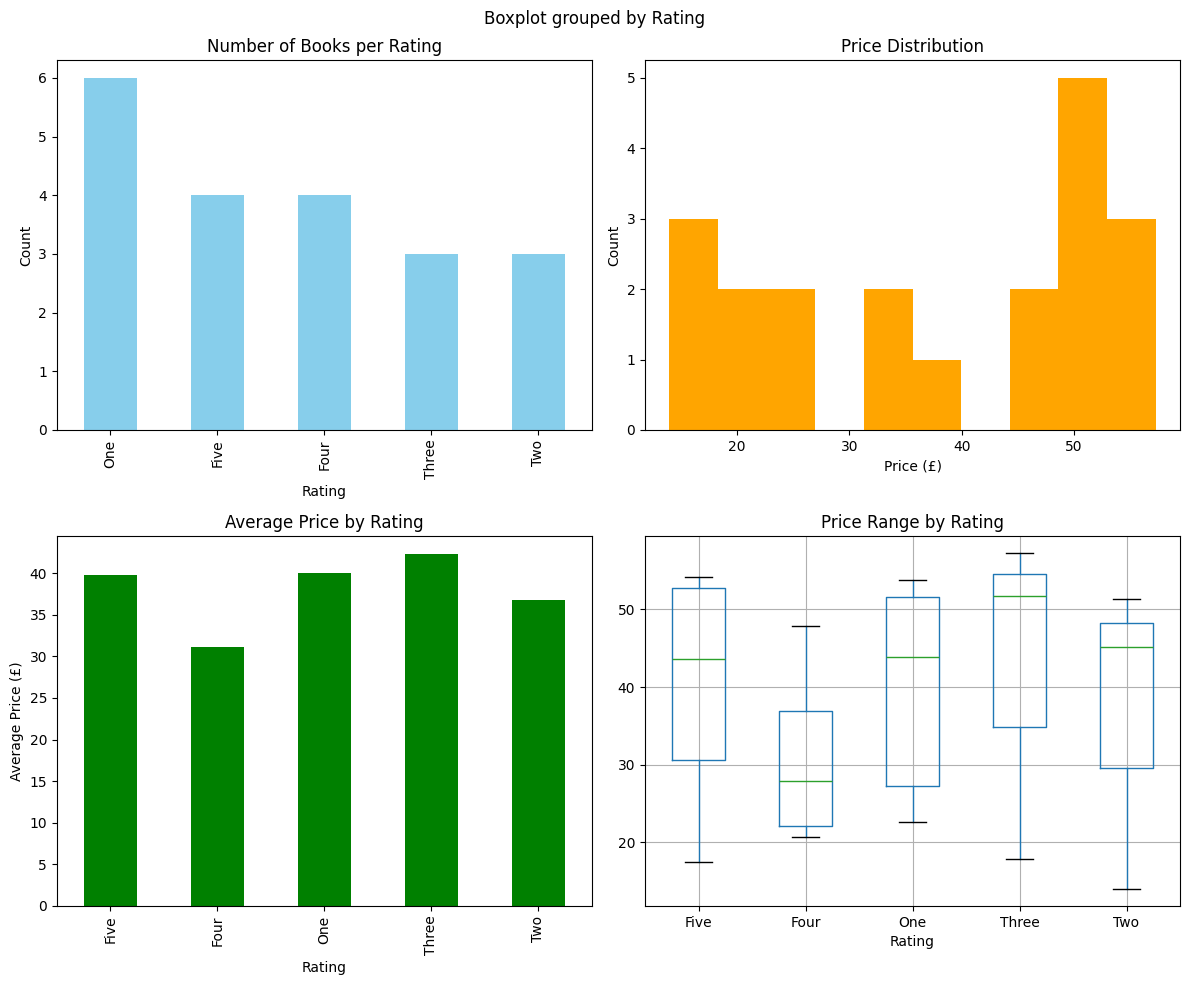

Charts saved!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Books Data Analysis', fontsize=16)

# Chart 1 - Books per Rating
df['Rating'].value_counts().plot(
    kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Number of Books per Rating')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')

# Chart 2 - Price Distribution
axes[0,1].hist(df['Price'], bins=10, color='orange')
axes[0,1].set_title('Price Distribution')
axes[0,1].set_xlabel('Price (£)')
axes[0,1].set_ylabel('Count')

# Chart 3 - Average Price by Rating
df.groupby('Rating')['Price'].mean().plot(
    kind='bar', ax=axes[1,0], color='green')
axes[1,0].set_title('Average Price by Rating')
axes[1,0].set_xlabel('Rating')
axes[1,0].set_ylabel('Average Price (£)')

# Chart 4 - Boxplot
df.boxplot(column='Price', by='Rating', ax=axes[1,1])
axes[1,1].set_title('Price Range by Rating')

plt.tight_layout()
plt.savefig('eda_charts.png')
plt.show()
print("Charts saved!")

In [ ]:
print("=== KEY INSIGHTS ===")
print(f"Total books analyzed: {len(df)}")
print(f"Average book price: £{df['Price'].mean():.2f}")
print(f"Most common rating: {df['Rating'].value_counts().index[0]}")
print(f"Most expensive book: {df.loc[df['Price'].idxmax(), 'Title']}")
print(f"Cheapest book: {df.loc[df['Price'].idxmin(), 'Title']}")
print(f"Highest rated avg price: £{df.groupby('Rating_Num')['Price'].mean().max():.2f}")

=== KEY INSIGHTS ===
Total books analyzed: 20
Average book price: £38.05
Most common rating: One
Most expensive book: Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Cheapest book: Starving Hearts (Triangular Trade Trilogy, #1)
Highest rated avg price: £42.32
